In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from rl4co.utils.trainer import RL4COTrainer

sys.path.append(str(Path('..').resolve() / 'src'))

from dvrptw_bench.data.instance_filters import find_rc_instances
from dvrptw_bench.data.solomon_parser import parse_solomon
from dvrptw_bench.paper_dynamic_routefinder import  DynamicAttentionRouteFinderPolicy
from dvrptw_bench.rl.routefinder_adapter import instance_to_routefinder_td, routefinder_actions_to_solution
from routefinder.envs.mtvrp import MTVRPGenerator
from routefinder.models import RouteFinderBase
from routefinder.utils import evaluate as evaluate_routefinder

from dvrptw_bench.rl.routefinder_adapter import (
    _normalize_coord_and_get_scale,
    instance_to_routefinder_td,
    routefinder_actions_to_solution,
)


In [ ]:
DATASET_ROOT = Path('../../dataset/')
OUTPUT_ROOT = Path('../../outputs/paper_dynamic_routefinder')
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_CUSTOMERS = 20
NUM_EPOCHS = 20
BATCH_SIZE = 256
TRAIN_DATA_SIZE = 100_000
VAL_DATA_SIZE = 1000
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-6
MAX_EVAL_INSTANCES = 5
DOD = 0.6
CUTOFF_RATIO = 0.8
DYNAMIC_SEED = 15
LATENESS_PENALTY = 100.0
REJECT_PENALTY = 1000.0
EVAL_BUDGET_S = 1.0

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'


In [9]:
def build_solomon_training_item(
    instance,
    num_customers,
    normalize_coords=True,
):
    customers = instance.customers[:num_customers]

    coords = [(instance.depot.x, instance.depot.y)] + [(c.x, c.y) for c in customers]
    locs_raw = torch.tensor(coords, dtype=torch.float32)

    if normalize_coords:
        locs, coord_scale_factor = _normalize_coord_and_get_scale(locs_raw)
    else:
        locs = locs_raw
        coord_scale_factor = 1.0

    ready = torch.tensor(
        [instance.depot.ready_time] + [c.ready_time for c in customers],
        dtype=torch.float32,
    )
    due = torch.tensor(
        [instance.depot.due_time] + [c.due_time for c in customers],
        dtype=torch.float32,
    )
    service_raw = torch.tensor(
        [0.0] + [c.service_time for c in customers],
        dtype=torch.float32,
    )
    demand = torch.tensor(
        [c.demand for c in customers],
        dtype=torch.float32,
    )

    time_windows_raw = torch.stack([ready, due], dim=-1)

    if normalize_coords:
        time_windows = time_windows_raw / coord_scale_factor
        service = service_raw / coord_scale_factor
    else:
        time_windows = time_windows_raw
        service = service_raw

    return {
        "locs": locs,
        "time_windows": time_windows,
        "service_time": service,
        "demand_linehaul": demand,
        "vehicle_capacity": float(instance.vehicle_capacity),
        "instance_id": instance.instance_id,
        "coord_scale_factor": coord_scale_factor,
    }





OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    device = torch.device("cuda")
    accelerator = "gpu"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
    accelerator = "mps"
else:
    device = torch.device("cpu")
    accelerator = "cpu"

device= torch.device('cpu')

print("Device:", device)
print("Dataset root:", DATASET_ROOT.resolve())
print("Output root:", OUTPUT_ROOT.resolve())

rc_instances = [
    parse_solomon(instance, max_customers=NUM_CUSTOMERS)
    for instance in find_rc_instances(DATASET_ROOT / 'solomon_rc100')
]
c_instances = [
    parse_solomon(instance, max_customers=NUM_CUSTOMERS)
    for instance in find_rc_instances(DATASET_ROOT / 'solomon_c100')
]

generator_solomon_instances = (
    [
        build_solomon_training_item(
            instance,
            num_customers=NUM_CUSTOMERS,
            normalize_coords=True,
        )
        for instance in rc_instances
    ]
    + [
        build_solomon_training_item(
            instance,
            num_customers=NUM_CUSTOMERS,
            normalize_coords=True,
        )
        for instance in c_instances
    ]
)

print(f"Training pool size: {len(generator_solomon_instances)}")
print(generator_solomon_instances[:1])


Device: cpu
Dataset root: /Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/dataset
Output root: /Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/outputs/paper_dynamic_routefinder
Training pool size: 8
[{'locs': tensor([[0.5000, 0.5625],
        [0.3125, 1.0000],
        [0.2750, 0.8750],
        [0.2750, 1.0000],
        [0.2500, 0.9375],
        [0.2500, 1.0000],
        [0.2250, 0.8750],
        [0.1875, 0.8750],
        [0.1875, 0.9375],
        [0.1250, 0.3750],
        [0.1250, 0.4375],
        [0.1000, 0.4375],
        [0.1000, 0.5000],
        [0.0625, 0.3750],
        [0.0625, 0.5000],
        [0.0250, 0.4375],
        [0.0000, 0.4375],
        [0.0000, 0.5000],
        [0.5500, 0.0000],
        [0.5250, 0.0625],
        [0.5250, 0.1250]]), 'time_windows': tensor([[ 0.0000, 12.0000],
        [ 8.4125,  9.9125],
        [ 1.9000,  3.4000],
        [ 5.8875,  7.3875],
        [ 8.0500,  9.5500],
        [ 0.9125,  2.4125],
        [ 4.8500,  6.3500],
       

In [ ]:

from routefinder.utils import rollout, greedy_policy, evaluate
from dvrptw_bench.paper_dynamic_routefinder.generator import DynamicGenerator
from dvrptw_bench.rl.env_dynamic import MTVRPDynamicEnv


generator = DynamicGenerator(num_loc=NUM_CUSTOMERS,solomon_instances=generator_solomon_instances, max_time=10.11, variant_preset='vrptw')
env = MTVRPDynamicEnv(
    generator=generator,
    # check_solution=False,
    # dod=DOD,
    # cutoff_time=CUTOFF_RATIO,
    # allow_late_customers=True,
    # lateness_penalty=LATENESS_PENALTY,
    # allow_reject_customers=True,
    # reject_penalty=REJECT_PENALTY,
    # dynamic_seed=DYNAMIC_SEED,
)
policy = DynamicAttentionRouteFinderPolicy(env_name=env.name).to(device)
model = RouteFinderBase(
    env,
    policy,
    batch_size=BATCH_SIZE,
    train_data_size=TRAIN_DATA_SIZE,
    val_data_size=VAL_DATA_SIZE,
    optimizer_kwargs={'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY},
)
trainer = RL4COTrainer(max_epochs=NUM_EPOCHS, accelerator=accelerator, devices=1, logger=None, num_sanity_val_steps=0)
trainer.fit(model)
checkpoint_path = './dynamic_attention_routefinder.ckpt'
trainer.save_checkpoint(str(checkpoint_path))
print('Saved checkpoint to', checkpoint_path)

# evaluate one generator instance
# td_data = generator(1)
# td_test = env.reset(td_data)
# td_test = td_test.to(device)
# model = model.to(device)
# out = evaluate(model, td_test.clone())

# actions = out["best_aug_actions"]
# rewards = env.get_reward(td_test, actions)
# rewards


/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'env' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['env'])`.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'policy' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['policy'])`.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamle

┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type                              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ env      │ MTVRPDynamicEnv                   │      0 │ train │     0 │
│ 1 │ policy   │ DynamicAttentionRouteFinderPolicy │  1.3 M │ train │     0 │
│ 2 │ baseline │ SharedBaseline                    │      0 │ train │     0 │
└───┴──────────┴───────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 112                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.venv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (40) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/Users/giuseppe/Documents/personal/fyp-vrp/dvrptw-benchmark/.

`Trainer.fit` stopped: `max_epochs=20` reached.


`weights_only` was not set, defaulting to `False`.


Saved checkpoint to ./dynamic_attention_routefinder.ckpt


In [11]:
instance_paths = find_rc_instances(DATASET_ROOT)[:MAX_EVAL_INSTANCES]
instances = [parse_solomon(path, max_customers=NUM_CUSTOMERS) for path in instance_paths]

def rollout_actions(eval_env, td_reset, actions):
    state = td_reset.clone()
    action_seq = actions[0].detach().cpu().tolist()
    for token in action_seq:
        state.update({'action': torch.tensor([int(token)], device=state.device)})
        state = eval_env._step(state)
        if bool(state['done'].item()):
            break
    return state

rows = []
for instance in instances:
    td = instance_to_routefinder_td(instance, normalize_coords=True).to(device)
    td_reset = env.reset(td)
    model.to(device).eval()
    with torch.inference_mode():
        out = evaluate_routefinder(model, td_reset.clone(), num_augment=8)
        actions = out.get('best_aug_actions', out.get('best_multistart_actions', out.get('actions')))
    td_final = rollout_actions(env, td_reset, actions)
    solution = routefinder_actions_to_solution(actions, instance, strategy='dynamic-attention-routefinder')
    rows.append({
        'instance_id': instance.instance_id,
        'dynamic_customers': int(td_reset['is_dynamic'][0, 1:].sum().item()),
        'hidden_initial': int((~td_reset['revealed'][0, 1:]).sum().item()),
        'cost' : solution.total_distance,
        # 'tardiness': float(td_final['total_tardiness'][0, 0].item()),
        # 'unserved': int((~td_final['visited'][0, 1:]).sum().item()),
        # 'auto_rejected': bool(td_final['auto_rejected'][0].item()),
        'routes': len([route for route in solution.routes if route.node_ids]),
    })
results = pd.DataFrame(rows)
# results['objective_proxy'] = LATENESS_PENALTY * results['tardiness'] + REJECT_PENALTY * results['unserved']
results


,instance_id,dynamic_customers,hidden_initial,cost,routes
0,RC201.txt,0,0,0.0,5
1,RC202.txt,0,0,0.0,3
2,RC203.txt,0,0,0.0,2
3,RC204.txt,0,0,0.0,3
4,RC205.txt,0,0,0.0,3


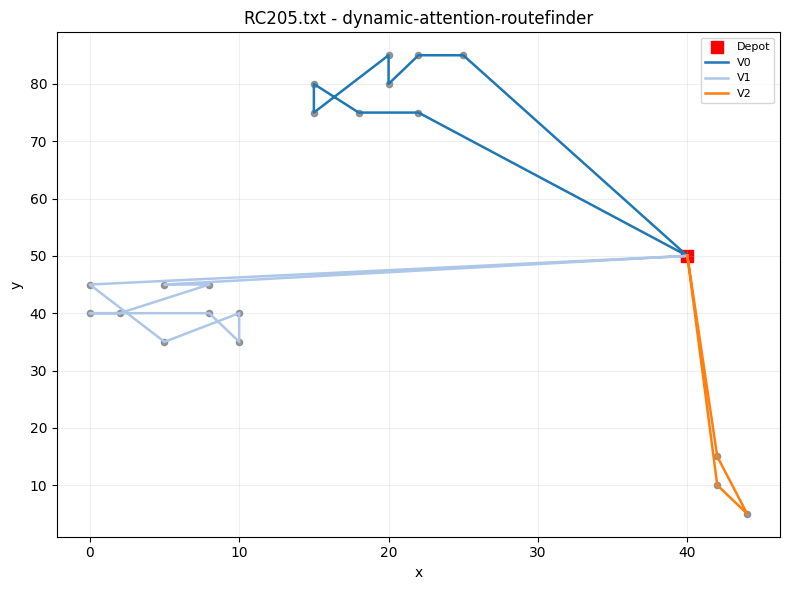

In [12]:

from dvrptw_bench.viz.route_plot import plot_routes


plot_routes(instance,solution)